In [1]:
from selenium import webdriver as wb
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
import time

In [2]:
#driver = wb.Chrome()
#driver.get('https://www.gmarket.co.kr/n/best')

#### 로봇으로 감지됨
- 최근 크롤링을 막는게 여러 홈페이지의 추세 -> 데이터 보안(고객정보 빼돌리기), 서버 공격(디도스) 등...
- 방법은 2가지 : req로 시도해보기 or 새로운 크롬드라이버를 사용하는 방법(이방법으로 해볼거다)
- 지마켓은 정보를 상업적으로 이용할까봐 막아두었다. 

In [3]:
# 라이브러리 설치 
# 우리는 크롤링까진 해도 되지만 상업적으로 이용하면 안된다. 정책 잘 확인하자.
#!pip install undetected_chromedriver

In [4]:
import undetected_chromedriver as uc

In [5]:
#!pip install webdriver_manager
#!pip install -U selenium

In [6]:
# 사용 방법은 똑같음
#from selenium.webdriver.chrome.service import Service
# 사용자가 사용하는 최신버전의 크롬 드라이버와 일치하는 드라이버를 찾아주는 라이브러리
#from webdriver_manager.chrome import ChromeDriverManager
# 최신버전의 크롬 드라이버를 찾고 다운로드 해주는 라이브러리
# ChromeDriverManager().install()  : 크롬드라이버 업데이트 및 설치
driver = uc.Chrome(version_main = 153)
driver.get("https://www.gmarket.co.kr/n/best")

In [7]:
# 상품 이름 수집
# 상품 리뷰 수집
# 20개 상품 이름과 리뷰를 모두 수집해보자

In [8]:
# 1. 클릭하려는 메뉴 리스트 정리된 변수
# 2. 하나씩 클릭
# 3. 상세 페이지에서 상품명 수집
# 4. 상품 리뷰 클릭
# 5. 상품 리뷰 수집
# 6. 다시 쥐마켓 베스트 상품 페이지로 접근
# 7. 20개 수집하면 끝!

In [9]:
#driver = uc.Chrome(version_main = 153)
#driver.get("https://www.gmarket.co.kr/n/best")

In [10]:
title = driver.find_elements(By.CSS_SELECTOR, "div.box__item-info")
len(title)

200

In [11]:
# 1번 상품 클릭해보기
title[0].click()

In [12]:
menu = driver.find_element(By.CSS_SELECTOR, "h1.itemtit")
menu.text

'벤트너 20인치 여행용 캐리어 기내반입 기내용 여행가방 케리어가방 수하물 가벼운 튼튼한 (예약 판매)'

In [13]:
review_a = driver.find_element(By.CSS_SELECTOR, "a#vip-tab-anchor")
review_a.click()

In [15]:
review = driver.find_elements(By.CSS_SELECTOR, "p.con")
review[0].text

'가격좋네요. 만족합니다. 흠집 덜 티날거같아 본드로 골랐어요. 고장안나고 오래썼음 좋겠네요.'

In [16]:
# 1번 방법(비추 -> 원래 가지고 있던 태그 정보들을 까먹을수 있음)
driver.back()

In [17]:
# 2번 방법
driver.get("https://www.gmarket.co.kr/n/best")

In [18]:
# 하나의 셀만 실행해도 Gmarket 페이지에 있는 
# 모든 상품 이름과 리뷰를 수집할 수 있는 로직 구현
driver = uc.Chrome(version_main = 153)
driver.get("https://www.gmarket.co.kr/n/best")
time.sleep(7)
all_re = {}

for i in range(10):
    review_lst = []
    title = driver.find_elements(By.CSS_SELECTOR, "div.box__item-info")
    title[i].click()   # 베스트페이지 -> 상품 클릭
    time.sleep(7)
    menu = driver.find_element(By.CSS_SELECTOR, "h1.itemtit")  # 상품의 이름
    # --> dict의 key값이 됨    
    review_a = driver.find_element(By.CSS_SELECTOR, "a#vip-tab-anchor")
    review_a.click()   # 리뷰가 모여있는 페이지로 이동!
    time.sleep(7)
    review = driver.find_elements(By.CSS_SELECTOR, "p.con")
    for j in range(len(review)):
        review_lst.append(review[j].text)   # 상품의 리뷰 수집 -> value값이 됨
    
    all_re[menu.text] = review_lst
    driver.get("https://www.gmarket.co.kr/n/best")
    time.sleep(7)

all_re

{'벤트너 20인치 여행용 캐리어 기내반입 기내용 여행가방 케리어가방 수하물 가벼운 튼튼한 (예약 판매)': ['가격좋네요. 만족합니다. 흠집 덜 티날거같아 본드로 골랐어요. 고장안나고 오래썼음 좋겠네요.',
  '캐리어 깔끔하고 좋아요. 여행갈때 잘 쓸수 있겠어요. 좋아요.',
  '작은애 기숙사 때문에 24인치 하나 더 살까하다 친정부모님이 산 쓴다해서 28인치 너무 크나 싶어 하나살까말까 고민하다 남편몰래 고민하다 질럿는데 잘 산거 같아요',
  '가성비로 캐리어 찾다가 구매했는데 좋아요.',
  '생각보다 크네요. 이뻐요. 아들 딸 잘 끌고다닐꺼같네요.',
  '적극추천 합니다. 배송이 빠릅니다.',
  '적극추천 합니다. 배송이 빠릅니다.',
  '추천 합니다. 배송이 빠릅니다.',
  '적극추천 합니다. 배송이 빠릅니다.',
  '추천 합니다. 배송이 보통입니다.',
  '적극추천 합니다. 배송이 빠릅니다.',
  '가성비 좋아요',
  '적극추천 합니다. 배송이 빠릅니다.',
  '적극추천 합니다. 배송이 빠릅니다.',
  '적극추천 합니다. 배송이 빠릅니다.'],
 '(신선집중)(농할20%) 제주 첫출하 햇조생 감귤 로얄과(S-M) 실중량 2.5kg': ['오래전부터 지마켓에서 서귀포인정 귤 자주 사먹었는데요~^^ 이번에도 믿고 주문했는데 새콤달콤 맛있어용~ 집에 귤귀신이 많아서 금방 다 먹을것같아요~ 행사하면 또 살께용',
  '슬슬 귤 익어가는 시기인데 하우스감귤도 푸릇하기는 하지만 맛있게 익었네요 중과라 소과보다 사이즈도 좋고 먹기좋네요 금방 순삭되는 바람에 재주문합니다~',
  '꼼꼼한 포장에 배송도 빨리 왔어요 저번에 시킨곳은 밍밍한 귤이 와서 실패했는데 이번엔 대성공이에요 여기 등록시켜 놓고 자주 주문하러 올께요 달코~옴 한데 끝에 살짝 새콤하니 딱 제가 좋아하는 맛이에요!!',
  '제주도 여름에 여행가면 500g 한팩에 7천원에 주고 사먹은것 같은데요 가격 좋아서 구매해봈는데 배송도 빨리 오고 만족 합니다~! 겨울에 먹던 귤은 아니

In [19]:
all_re.keys()

dict_keys(['벤트너 20인치 여행용 캐리어 기내반입 기내용 여행가방 케리어가방 수하물 가벼운 튼튼한 (예약 판매)', '(신선집중)(농할20%) 제주 첫출하 햇조생 감귤 로얄과(S-M) 실중량 2.5kg', '(농할20%)(2kg이상무배) 국내산 1등급 한돈 돼지고기 목살 냉장 1kg', '(신선집중) 제주농협 귤로장생 하우스감귤 4.5kg 소과', '카누 미니 마일드 아메리카노 120Tx2개 외 2종 골라담기', '농심 누룽지팝 오리지널 3개 + 매콤한맛 3개', '(신선집중)(농할20%) 전남 나주배 신고배 6-10과 5kg', '(버거킹) 와퍼주니어+불고기와퍼주니어+콜라R+콜라R+프렌치프라이R', '(신선집중) 본가명인 국내산 배추김치 포기김치 10kg 전재료 100% 국산 강원도 고랭지배추 당일생산 생김치', '육식토끼 닭가슴살 소시지 80g 다이어트 간식 베스트맛 5종 선택 30팩 (15팩+15팩)'])

In [20]:
all_re.values()

dict_values([['가격좋네요. 만족합니다. 흠집 덜 티날거같아 본드로 골랐어요. 고장안나고 오래썼음 좋겠네요.', '캐리어 깔끔하고 좋아요. 여행갈때 잘 쓸수 있겠어요. 좋아요.', '작은애 기숙사 때문에 24인치 하나 더 살까하다 친정부모님이 산 쓴다해서 28인치 너무 크나 싶어 하나살까말까 고민하다 남편몰래 고민하다 질럿는데 잘 산거 같아요', '가성비로 캐리어 찾다가 구매했는데 좋아요.', '생각보다 크네요. 이뻐요. 아들 딸 잘 끌고다닐꺼같네요.', '적극추천 합니다. 배송이 빠릅니다.', '적극추천 합니다. 배송이 빠릅니다.', '추천 합니다. 배송이 빠릅니다.', '적극추천 합니다. 배송이 빠릅니다.', '추천 합니다. 배송이 보통입니다.', '적극추천 합니다. 배송이 빠릅니다.', '가성비 좋아요', '적극추천 합니다. 배송이 빠릅니다.', '적극추천 합니다. 배송이 빠릅니다.', '적극추천 합니다. 배송이 빠릅니다.'], ['오래전부터 지마켓에서 서귀포인정 귤 자주 사먹었는데요~^^ 이번에도 믿고 주문했는데 새콤달콤 맛있어용~ 집에 귤귀신이 많아서 금방 다 먹을것같아요~ 행사하면 또 살께용', '슬슬 귤 익어가는 시기인데 하우스감귤도 푸릇하기는 하지만 맛있게 익었네요 중과라 소과보다 사이즈도 좋고 먹기좋네요 금방 순삭되는 바람에 재주문합니다~', '꼼꼼한 포장에 배송도 빨리 왔어요 저번에 시킨곳은 밍밍한 귤이 와서 실패했는데 이번엔 대성공이에요 여기 등록시켜 놓고 자주 주문하러 올께요 달코~옴 한데 끝에 살짝 새콤하니 딱 제가 좋아하는 맛이에요!!', '제주도 여름에 여행가면 500g 한팩에 7천원에 주고 사먹은것 같은데요 가격 좋아서 구매해봈는데 배송도 빨리 오고 만족 합니다~! 겨울에 먹던 귤은 아니더라도 이 시기에 귤 먹으니 부자 된 느낌이네요 좋은가격에 판매해주셔서 감사합니다', '상태 좋은 귤 잘 받았습니다. 맛있어요.', '좋아요', '적극추천 합니다. 배송이 빠릅니다.', '추천 안 합니다. 배송이 보통입니다.', '적극추천

In [21]:
lst_temp = list(all_re.values())

In [22]:
lst_temp[0]

['가격좋네요. 만족합니다. 흠집 덜 티날거같아 본드로 골랐어요. 고장안나고 오래썼음 좋겠네요.',
 '캐리어 깔끔하고 좋아요. 여행갈때 잘 쓸수 있겠어요. 좋아요.',
 '작은애 기숙사 때문에 24인치 하나 더 살까하다 친정부모님이 산 쓴다해서 28인치 너무 크나 싶어 하나살까말까 고민하다 남편몰래 고민하다 질럿는데 잘 산거 같아요',
 '가성비로 캐리어 찾다가 구매했는데 좋아요.',
 '생각보다 크네요. 이뻐요. 아들 딸 잘 끌고다닐꺼같네요.',
 '적극추천 합니다. 배송이 빠릅니다.',
 '적극추천 합니다. 배송이 빠릅니다.',
 '추천 합니다. 배송이 빠릅니다.',
 '적극추천 합니다. 배송이 빠릅니다.',
 '추천 합니다. 배송이 보통입니다.',
 '적극추천 합니다. 배송이 빠릅니다.',
 '가성비 좋아요',
 '적극추천 합니다. 배송이 빠릅니다.',
 '적극추천 합니다. 배송이 빠릅니다.',
 '적극추천 합니다. 배송이 빠릅니다.']

In [23]:
w = ",".join([lst for lst in lst_temp[0]])
w

'가격좋네요. 만족합니다. 흠집 덜 티날거같아 본드로 골랐어요. 고장안나고 오래썼음 좋겠네요.,캐리어 깔끔하고 좋아요. 여행갈때 잘 쓸수 있겠어요. 좋아요.,작은애 기숙사 때문에 24인치 하나 더 살까하다 친정부모님이 산 쓴다해서 28인치 너무 크나 싶어 하나살까말까 고민하다 남편몰래 고민하다 질럿는데 잘 산거 같아요,가성비로 캐리어 찾다가 구매했는데 좋아요.,생각보다 크네요. 이뻐요. 아들 딸 잘 끌고다닐꺼같네요.,적극추천 합니다. 배송이 빠릅니다.,적극추천 합니다. 배송이 빠릅니다.,추천 합니다. 배송이 빠릅니다.,적극추천 합니다. 배송이 빠릅니다.,추천 합니다. 배송이 보통입니다.,적극추천 합니다. 배송이 빠릅니다.,가성비 좋아요,적극추천 합니다. 배송이 빠릅니다.,적극추천 합니다. 배송이 빠릅니다.,적극추천 합니다. 배송이 빠릅니다.'

In [24]:
type(w)

str

#### 참고 : WordCloud 사용하기

In [26]:
!pip install wordcloud

In [27]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(font_path = "C:Windows/Fonts/malgunbd.ttf",
              background_color = "white",
              colormap = "Dark2").generate(w)
wc.words_

{'합니다 배송이': 1.0,
 '배송이 빠릅니다': 0.8888888888888888,
 '적극추천 합니다': 0.7777777777777778,
 '좋아요': 0.4444444444444444,
 '잘': 0.3333333333333333,
 '캐리어': 0.2222222222222222,
 '고민하다': 0.2222222222222222,
 '추천': 0.2222222222222222,
 '가격좋네요': 0.1111111111111111,
 '만족합니다': 0.1111111111111111,
 '흠집': 0.1111111111111111,
 '덜': 0.1111111111111111,
 '티날거같아': 0.1111111111111111,
 '본드로': 0.1111111111111111,
 '골랐어요': 0.1111111111111111,
 '고장안나고': 0.1111111111111111,
 '오래썼음': 0.1111111111111111,
 '좋겠네요': 0.1111111111111111,
 '깔끔하고': 0.1111111111111111,
 '여행갈때': 0.1111111111111111,
 '쓸수': 0.1111111111111111,
 '있겠어요': 0.1111111111111111,
 '작은애': 0.1111111111111111,
 '기숙사': 0.1111111111111111,
 '때문에': 0.1111111111111111,
 '24인치': 0.1111111111111111,
 '하나': 0.1111111111111111,
 '더': 0.1111111111111111,
 '살까하다': 0.1111111111111111,
 '친정부모님이': 0.1111111111111111,
 '산': 0.1111111111111111,
 '쓴다해서': 0.1111111111111111,
 '28인치': 0.1111111111111111,
 '너무': 0.1111111111111111,
 '크나': 0.1111111111111111,
 '싶어': 0.1111

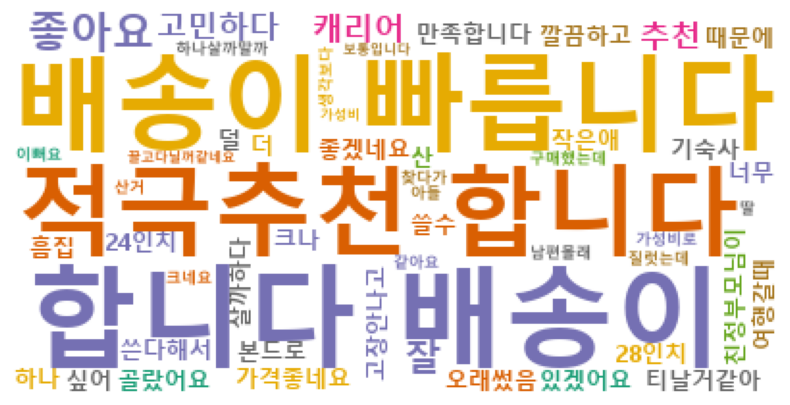

In [28]:
plt.figure(figsize = (12,5))
plt.axis('off')
plt.imshow(wc)
plt.savefig("워드크라우드결과.jpg")

In [ ]:
# 보통 선거자료로 많이 사용됨.
# 프로젝트 할때 사용해보길 바람.
#from wordcloud import WordCloud
#import matplotlib.pyplot as plt

#wc = WordCloud(font_path = "C:/Windows/Fonts/malgunbd.ttf",
              background_color = "white",
              colormap = "Dark2").generate(w)
#wc.words_

In [ ]:
#plt.figure(figsize = (12, 5))
#plt.axis('off')
#plt.imshow(wc)
#plt.savefig("워드클라우드결과.jpg")